In [1]:
!pip install pandas matplotlib seaborn psycopg2-binary SQLAlchemy python-dotenv

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import matplotlib.dates as mdates

import os
from dotenv import load_dotenv

In [3]:
db_user = os.getenv('POSTGRES_USER')
db_password = os.getenv('POSTGRES_PASSWORD')
db_host = '26.212.102.0'
db_port = '5432'
db_name = os.getenv('POSTGRES_DB')

db_url = f'postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}'

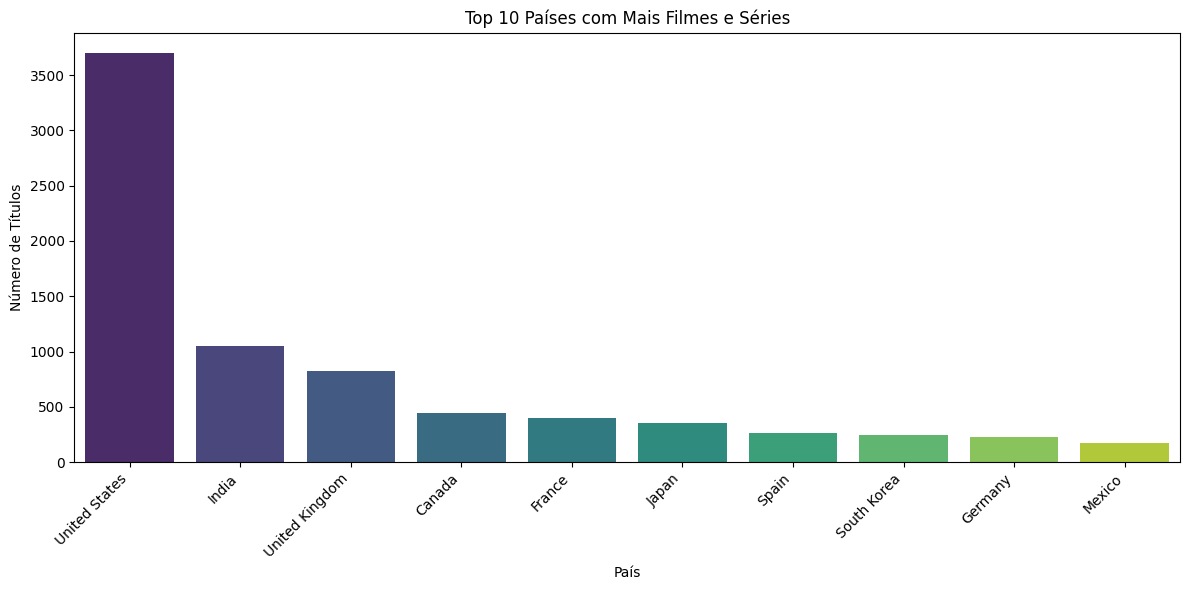

In [4]:
try:
    engine = create_engine(db_url)

    query = """
        SELECT
            c.name AS country,
            COUNT(tbc.show_id) AS title_count
        FROM
            countries AS c
        JOIN
            titles_by_country AS tbc ON c.id = tbc.country_id
        GROUP BY
            c.name
        ORDER BY
            title_count DESC
        LIMIT 10;
    """

    df_top_countries = pd.read_sql(query, engine)

    df_top_countries['country'] = df_top_countries['country'].str.title()
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x='country', y='title_count', data=df_top_countries, palette='viridis', hue='country', legend=False)
    plt.title('Top 10 Países com Mais Filmes e Séries')
    plt.xlabel('País')
    plt.ylabel('Número de Títulos')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    output_folder = 'graficos'
    os.makedirs(output_folder, exist_ok=True)
    plt.savefig(os.path.join(output_folder, 'top_10_paises_db.png')) 

    plt.show()

except Exception as e:
    print(f"Ocorreu um erro: {e}")


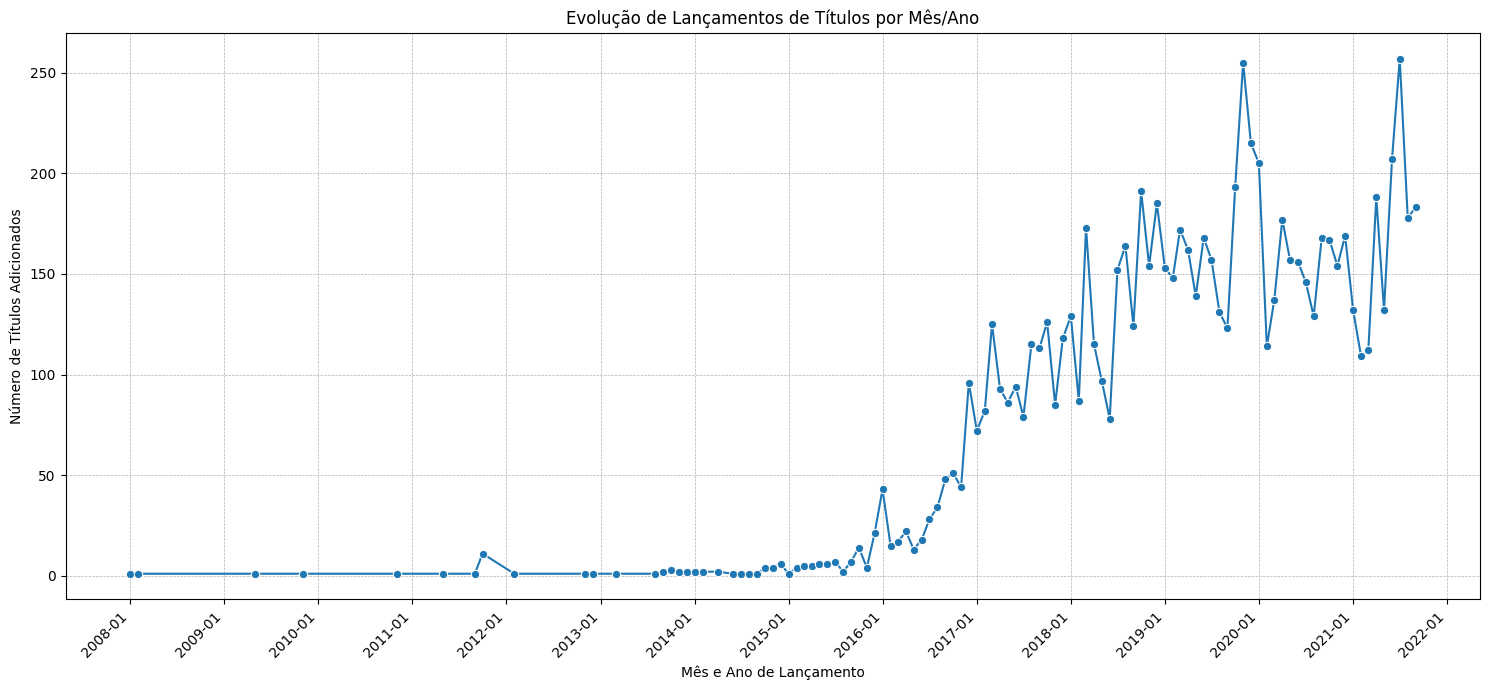

In [5]:
try:
    engine = create_engine(db_url)

    query = """
        SELECT
            TO_CHAR(date_added, 'YYYY-MM') AS release_month_year,
            COUNT(id) AS title_count
        FROM
            titles_clean
        WHERE
            date_added IS NOT NULL
        GROUP BY
            release_month_year
        ORDER BY
            release_month_year;
    """

    df_evolution = pd.read_sql(query, engine)

    df_evolution['release_month_year'] = pd.to_datetime(df_evolution['release_month_year'], format='%Y-%m')

    plt.figure(figsize=(15, 7))
    sns.lineplot(x='release_month_year', y='title_count', data=df_evolution, marker='o')

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.YearLocator()) 
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    plt.title('Evolução de Lançamentos de Títulos por Mês/Ano')
    plt.xlabel('Mês e Ano de Lançamento')
    plt.ylabel('Número de Títulos Adicionados')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    output_folder = 'graficos'
    os.makedirs(output_folder, exist_ok=True)
    plt.savefig(os.path.join(output_folder, 'evolucao_lancamentos.png')) 
    
    plt.show()

except Exception as e:
    print(f"Ocorreu um erro: {e}")

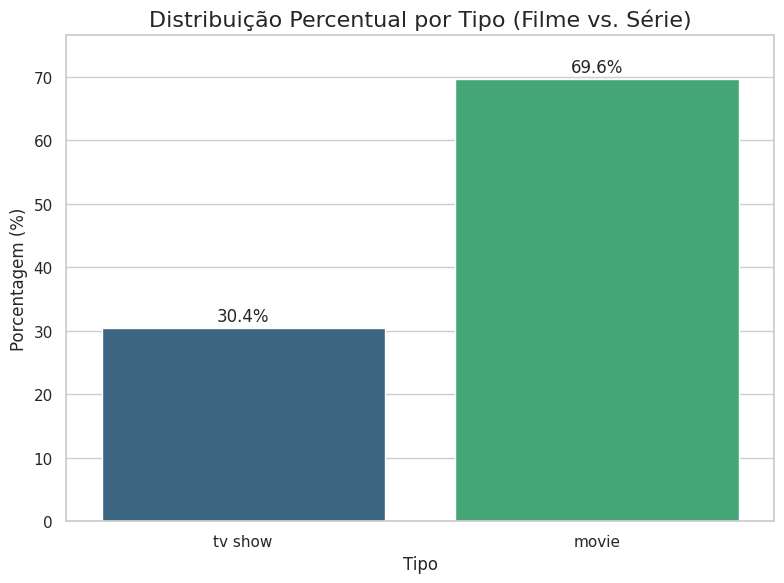

In [6]:
try:
    engine = create_engine(db_url)

    query = """
        SELECT
            type,
            COUNT(id) AS total
        FROM
            titles_clean
        GROUP BY
            type;
    """

    df_type = pd.read_sql(query, engine)

    total_geral = df_type['total'].sum()
    df_type['percentage'] = (df_type['total'] / total_geral) * 100

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(8, 6))

    ax = sns.barplot(
        x='type',
        y='percentage', 
        data=df_type,
        palette='viridis',
        hue='type',
        legend=False
    )

    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=12)

    # 4. ATUALIZA TÍTULOS E RÓTULOS
    plt.title('Distribuição Percentual por Tipo (Filme vs. Série)', fontsize=16)
    plt.xlabel('Tipo', fontsize=12)
    plt.ylabel('Porcentagem (%)', fontsize=12) 
    plt.xticks(rotation=0) 

    ax.set_ylim(0, max(df_type['percentage']) * 1.1)

    plt.tight_layout()

    output_folder = 'graficos'
    os.makedirs(output_folder, exist_ok=True)
    plt.savefig(os.path.join(output_folder, 'percentual_por_tipo_barras.png'), dpi=300)
    
    plt.show()

except Exception as e:
    print(f"Ocorreu um erro: {e}")

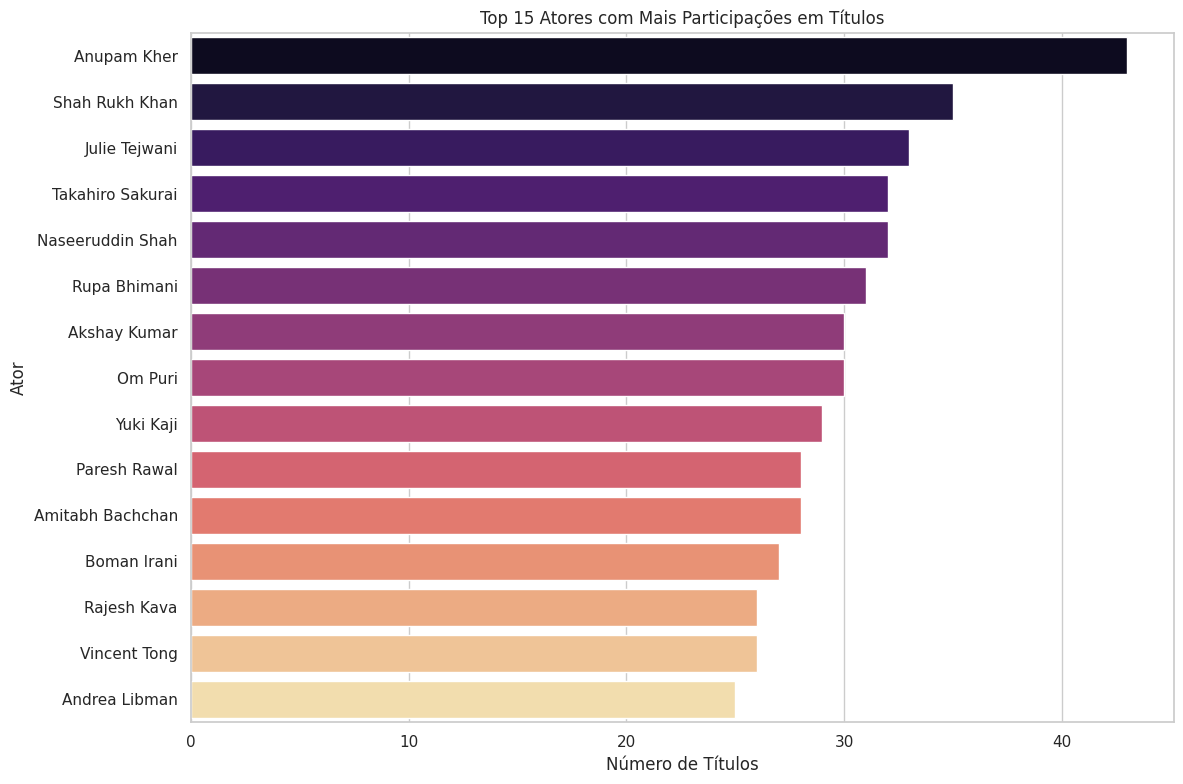

In [7]:
try:
    engine = create_engine(db_url)

    query = """
        SELECT
            a.name AS actor,
            COUNT(tba.show_id) AS title_count
        FROM
            actors AS a
        JOIN
            titles_by_actor AS tba ON a.id = tba.actor_id
        GROUP BY
            a.name
        ORDER BY
            title_count DESC
        LIMIT 15;
    """

    df_actors = pd.read_sql(query, engine)

    plt.figure(figsize=(12, 8))

    sns.barplot(
        x='title_count',
        y='actor',
        data=df_actors.sort_values('title_count', ascending=False),
        palette='magma',
        hue='actor', 
        legend=False 
    )

    plt.title('Top 15 Atores com Mais Participações em Títulos')
    plt.xlabel('Número de Títulos')
    plt.ylabel('Ator')
    plt.tight_layout()

    output_folder = 'graficos'
    os.makedirs(output_folder, exist_ok=True)
    plt.savefig(os.path.join(output_folder, 'top_15_atores.png'), dpi=300)

    plt.show()

except Exception as e:
    print(f"Ocorreu um erro: {e}")

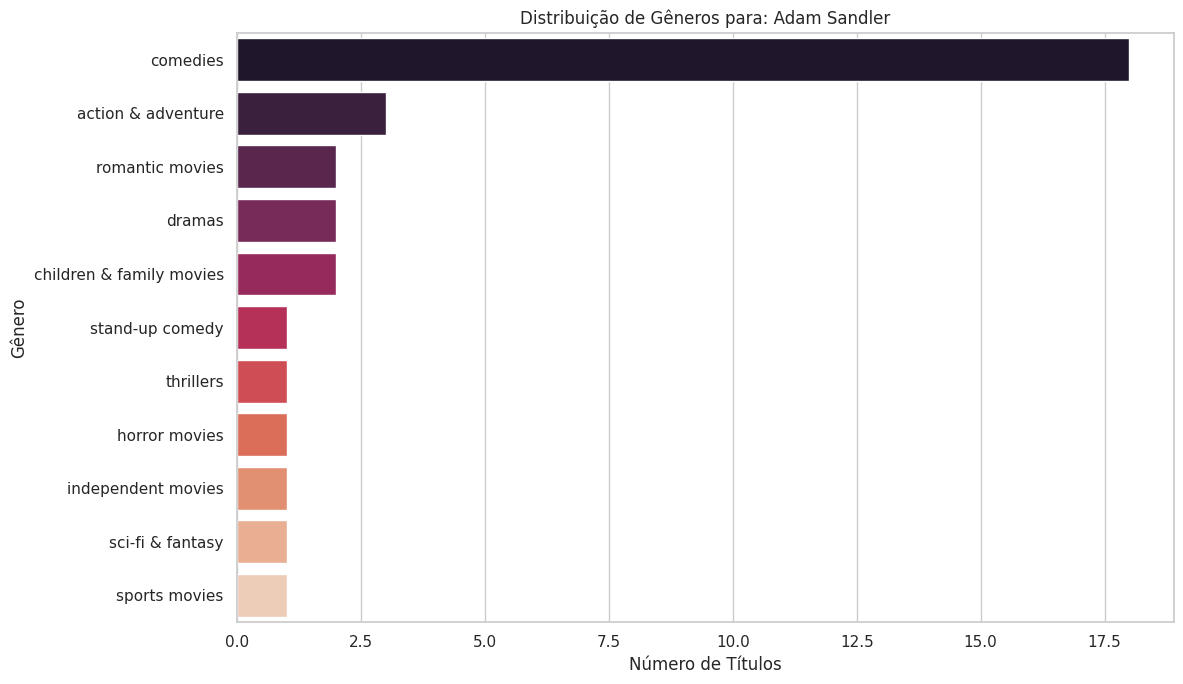

In [8]:
try:
    engine = create_engine(db_url)

    actor_name_to_analyze = 'Adam Sandler'

    query_genres = f"""
        SELECT
            g.name AS genre,
            COUNT(t.id) AS genre_count
        FROM
            actors AS a
        JOIN titles_by_actor AS tba ON a.id = tba.actor_id
        JOIN titles_clean AS t ON tba.show_id = t.id
        JOIN titles_by_genre AS tbg ON t.id = tbg.show_id
        JOIN genres AS g ON tbg.genre_id = g.id
        WHERE
            a.name = '{actor_name_to_analyze}'
        GROUP BY
            g.name
        ORDER BY
            genre_count DESC;
    """

    df_actor_genres = pd.read_sql(query_genres, engine)

    plt.figure(figsize=(12, 7))
    sns.barplot(
        x='genre_count',
        y='genre',
        data=df_actor_genres,
        palette='rocket',
        hue='genre',
        legend=False
    )
    plt.title(f'Distribuição de Gêneros para: {actor_name_to_analyze}')
    plt.xlabel('Número de Títulos')
    plt.ylabel('Gênero')
    plt.tight_layout()

    output_folder = 'graficos'
    os.makedirs(output_folder, exist_ok=True)
    plt.savefig(os.path.join(output_folder, 'generos_por_ator.png'), dpi=300)
    
    plt.show()

except Exception as e:
    print(f"Ocorreu um erro: {e}")